# Introduction · Approach 2

**Concept** <br>
Fit a *single GEV distribution* using annual maxima from **multiple years (pooled together)**, not separate GEVs for each year <br>
-> Separate analysis for different models and locations <br>


**Additional Notes**
- Using sim_year as the actual year 

**Notes on next steps:**
- 8 models × 680 locations = 5,440 independent analyses >> parallelize code on model level

**!!! ToDo**
- plot model fits
- create a mapping function for location info and lat/lon... store as JSON to save lookup
- add Confidence Intervals for Return Levels
- add CI to txt

**NOTE** paused for now (28.01.26)

# Import Libraries

In [1]:
import multiprocessing as mp
import random
import time
from datetime import datetime
from glob import glob
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import psutil
from pandas import concat

import func_gev as gev
import func_plotting as dbplt
import func_preparation as dbf
import func_utils as ut

# Settings

In [2]:
path = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/gev_analysis/per_model/'

In [3]:
hindcast_start = 1960
hindcast_end = 2026

In [4]:
return_periods = [10, 25, 50, 100, 200]
plot_period_evolution = ['10-year', '50-year', '100-year']

In [5]:
colors = [
    '#53354DFF','#7D4F73FF','#B887ADFF','#CAA5C2FF','#DBC3D6FF','#F5F5F5FF','#99E3DDFF',
    '#66D4CCFF','#33C6BBFF','#008A80FF','#005C55FF'
    ]

In [6]:
# For code parallelization later in the process 
print(f"Physical cores: {psutil.cpu_count(logical=False)}")
print(f"Logical cores: {psutil.cpu_count(logical=True)}")
print(f"Logical cores (mp): {mp.cpu_count()}")

Physical cores: 4
Logical cores: 8
Logical cores (mp): 8


# Import data

In [7]:
ls_files = [file for file in glob(path + '*.nc')]

test_models = ls_files[:3]

In [8]:
dic_data_per_model = dict()

for en, file in enumerate(test_models):
    model_name = file.split('/')[-1].split('.nc')[0].split('_')[-1]
    
    print(f'Importing data from model {model_name} ({en+1}/{len(ls_files)})...')
    model_name, ds_model = dbf.import_data_from_file(file) 
    
    dic_data_per_model[model_name] = dict({'raw data': ds_model})

Importing data from model MIROC6 (1/8)...
Importing data from model MPI-ESM1-2-HR (2/8)...
Importing data from model HadGEM3-GC31-MM (3/8)...


# Data Preparation 

BiasCorrection and Selection of valid data

In [9]:
en = 0 
for model_name, dic_data_model in dic_data_per_model.items():
    print(f'Processing model: {model_name} ({en+1}/{len(ls_files)})...')

    ds_model_corrected = dbf.bias_correction(dic_data_model['raw data'])
    dbf.verify_bias_correction(dic_data_model['raw data'], ds_model_corrected)
    print(f'\tBias correction successfully done and verified.')

    data_valid, sites_valid, sites_total, rate_invalid = dbf.select_valid_data(
        dic_data_model['raw data'], ds_model_corrected
    )
    print(
        f" - Site Selection done:\n"
        f"\tFrom {sites_total} sites, {sites_valid} are model_valid – removed {rate_invalid:.2f}% invalid sites."
    )
    
    dic_data_per_model[model_name]['valid data'] = data_valid
    dic_data_per_model[model_name]['preparation info'] = sites_valid, sites_total, rate_invalid
    en += 1
    print("-------------------------------------------------------------------------------------")
    print("")

Processing model: MIROC6 (1/8)...
 - Validating bias correction:
	Asserting whether actual ([0.82322574 0.75584654]) selection matches expected selection ([0.82322574 0.75584654])... 
	Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, 7054 are model_valid – removed 36.00% invalid sites.
-------------------------------------------------------------------------------------

Processing model: MPI-ESM1-2-HR (2/8)...
 - Validating bias correction:
	Asserting whether actual ([nan nan]) selection matches expected selection ([nan nan])... 
	Bias correction successfully done and verified.
 - Site Selection done:
	From 11022 sites, 5808 are model_valid – removed 47.31% invalid sites.
-------------------------------------------------------------------------------------

Processing model: HadGEM3-GC31-MM (3/8)...
 - Validating bias correction:
	Asserting whether actual ([0.58394538 0.73981713]) selection matches expected selection ([0.58394538 0.73981713]).

In [10]:
sites_valid = [dic_data_per_model[model_label]['preparation info'][0] for model_label in dic_data_per_model.keys()]

print("Data Overview")
print(
    f"Data is available from {len(test_models)} models (out of {len(ls_files)}) and "
    f"{min(sites_valid)}-{max(sites_valid)} locations"
    f""
)

Data Overview
Data is available from 3 models (out of 8) and 5808-7216 locations


Estimated processing time for 8 models: ~5min

# Workflow GEV - Generalized Extreme Value

## Initial try 

### Batch data to 5 locations all years

Create a batch of 5 locations. If this workflow works, we can batch and paralize the rest.

In [11]:
ls_models = list(dic_data_per_model.keys())
ls_models

['MIROC6', 'MPI-ESM1-2-HR', 'HadGEM3-GC31-MM']

In [12]:
dic_model_valid = dict(
    map(
        lambda ex_model: (ex_model, dic_data_per_model[ex_model]['valid data']),
        ls_models
    )
)

In [13]:
dic_locationsID_per_model = {}

for model_ in dic_model_valid.keys():
    locations_id = []
    while len(locations_id) < 5:
        locations_id.append(random.randint(0, dic_model_valid[model_].shape[-1]))    
    dic_locationsID_per_model[model_] = sorted(locations_id)
    
dic_locationsID_per_model

{'MIROC6': [30, 1391, 2559, 5943, 6832],
 'MPI-ESM1-2-HR': [2481, 3257, 3693, 4089, 4371],
 'HadGEM3-GC31-MM': [387, 3430, 4355, 4537, 6091]}

In [14]:
dic_batch_locations = {
    model_: dic_model_valid[model_][:, :, dic_locationsID_per_model[model_]] 
    for model_ in dic_model_valid.keys()
    }

In [15]:
dic_data = {}
df = None

for model_ in dic_batch_locations.keys():
    df = dic_batch_locations[model_].to_dataframe(name="value").reset_index()
    df['model'] = model_
    df.rename(columns={'value': 'storm_surge'}, inplace=True)
    dic_data[model_] = df
    
df = concat(dic_data).reset_index()

df.describe()

,level_1,sample,member,sites,sim_year,lead,lon,lat,bc_flag,storm_surge
count,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.000000,19900.00000,16175.000000
mean,3320.354271,331.585427,1.500000,5759.604020,1995.291457,5.500000,3.917828,46.067296,2.80000,0.575502
std,1922.040522,192.203838,0.500013,3027.335504,19.218237,2.872353,11.067833,10.234596,0.40001,0.432752
min,0.000000,0.000000,1.000000,39.000000,1961.000000,1.000000,-15.429903,28.184394,2.00000,0.051733
25%,1658.000000,165.000000,1.000000,3486.000000,1979.000000,3.000000,-5.495022,37.034207,3.00000,0.229780
50%,3316.000000,331.000000,1.500000,6469.000000,1995.000000,5.500000,3.126956,43.682002,3.00000,0.313629
75%,4974.250000,497.000000,2.000000,7754.000000,2012.000000,8.000000,10.644985,55.848038,3.00000,0.915319
max,6799.000000,679.000000,2.000000,10626.000000,2028.000000,10.000000,25.402530,63.689727,3.00000,2.211721


### Run Analysis

In [16]:
models: Optional[list] = None
locations: Optional[list] = None
time_start = time.time()

print("\n" + "="*70)
print("STORM SURGE GEV ANALYSIS - POOLED APPROACH PER MODEL")
print("="*70)

# ---------------------------------------------
df_prepared = ut.prepare_data(data=df, hindcast_start=hindcast_start, hindcast_end=hindcast_end)

# ---------------------------------------------
if models is None:
    models = df_prepared['model'].unique()

locations_total = df_prepared[['lon', 'lat']].drop_duplicates().reset_index()

results = {}
count = 0

print(f"\nAnalyzing {len(models)} model(s) and {len(locations_total)} different locations...")

for en_m, model_ in enumerate(models):
    print(f"\nProcessing model {model_} ({en_m+1}/{len(models)})")

    print("\tLookup location info for batch...")
    locations = df_prepared[df_prepared.model == model_][['lon', 'lat']].drop_duplicates().reset_index()
    
    locations_label = dbf.locations_label_lookup_batched(locations) 
    total = len(models) * len(locations)

    results[model_] = {}
    for en in locations.index:
        location_info = locations_label[en]
        print(f"\n\tAnalyse location {location_info[0]} (ID {dic_locationsID_per_model[model_][en]}) ")
        
        count += 1
        if count % 100 == 0 or count == total:
            print(f"  Progress: {count}/{total} ({100*count/total:.1f}%)")

        result = gev.analyze_location_per_model(
            df_prepared, model_, locations.loc[en].lat, locations.loc[en].lon, location_info[0], return_periods
            )

        if result is None:
            print(f"\t\t→ Warning! No results found, skipping...")
        else:
            results[model_][(locations.loc[en].lat, locations.loc[en].lon)] = result
            print(f"\t\t→ Results produced successfully; storing to dictionary...")

print("\n" + "="*70)
time_end = time.time()
print(f"✓ ANALYSIS COMPLETED IN {(time_end - time_start):.2f}s!")
print("="*70)


STORM SURGE GEV ANALYSIS - POOLED APPROACH PER MODEL

Data Summary:
  Hindcast period: 1960-2026
  Total observations: 17,650
  Models: 3
  Locations: 15

Analyzing 3 model(s) and 15 different locations...

Processing model MIROC6 (1/3)
	Lookup location info for batch...
	✓ Loaded 184 cached results
	Processing batch 1/1 (locations 0-5)


	Batch 1: 100%|██████████| 5/5 [00:08<00:00,  1.67s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Frøya, Trøndelag, Norge (ID 30) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Valdepomeda, A Cancela de Vilar, Millaral, Burela, A Mariña Central, Lugo, Galicia, 27880, España (ID 1391) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Στάουσα, Άγιος Στέφανος, Δήμος Βόρειας Κέρκυρας, Περιφερειακή Ενότητα Κέρκυρας, Περιφέρεια Ιονίων Νήσων, Αποκεντρωμένη Διοίκηση Πελοποννήσου, Δυτικής Ελλάδας και Ιονίου, 490 81, Ελλάς (ID 2559) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-sta

	Batch 1: 100%|██████████| 5/5 [00:08<00:00,  1.66s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location RL533, قلعة الأندلس, قلعة الأندلس الشرقية, معتمدية قلعة الأندلس, ولاية أريانة, 2022, تونس (ID 2481) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Remezzo, Φηρών - Περίσσας, Μεγαλοχώρι, Δημοτική Ενότητα Θήρας, Δήμος Θήρας, Περιφερειακή Ενότητα Θήρας, Περιφέρεια Νοτίου Αιγαίου, Αποκεντρωμένη Διοίκηση Αιγαίου, 847 00, Ελλάς (ID 3257) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Whicham, Cumberland, England, United Kingdom (ID 3693) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
		

	Batch 1: 100%|██████████| 5/5 [00:08<00:00,  1.67s/it]


	✓ Batch 1 saved to cache
	✓ All batches complete: 5/5 successful

	Analyse location Esby naturlejrplads, Esby Strandvej, Esby, Syddjurs Kommune, Region Midtjylland, Danmark (ID 387) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location RN16, Zone Franche Logistique, Eddalya ⴷⴰⵍⵢⴰ الدالية, Ksar El Majaz ⵇⵚⴰⵔ ⵍⵎⵊⴰⵣ قصر المجاز, caïdat de Ksar El Majaz, Cercle d'Anjra دائرة أنجرة, Province de Fahs-Anjra إقليم الفحص-أنجرة, Tanger-Tétouan-Al Hoceïma ⵟⴰⵏⵊ-ⵟⵉⵜⴰⵡⵉⵏ-ⵍⵃⵓⵙⵉⵎⴰ طنجة تطوان الحسيمة, Maroc ⵍⵎⵖⵔⵉⴱ المغرب (ID 3430) 
		conducting stationary GEV...
			stationary GEV done (success True); continuing with non-stationary GEV...
			non-stationary GEV done (success True).
		→ Results produced successfully; storing to dictionary...

	Analyse location Porto Rifugio, Via Stentinello, Siracusa, Sicilia, Italia (ID 4355) 
		c

## Show results for one location


In [17]:
results.keys()

dict_keys(['MIROC6', 'MPI-ESM1-2-HR', 'HadGEM3-GC31-MM'])

In [18]:
result_display = None
example_model = None

example_model = input('select model ')

if example_model:
    print(f"selected model {example_model} for result display")
    
    result = results[example_model]

    location_in_model = [results[example_model][loc_]['location info'] for loc_ in list(result.keys())]
    print("locations available in model:")
    for en, loc in enumerate(location_in_model):
        print(f"\t{en+1} – {loc}")
    location_choice = input('select location (lat/lon) ')
    
    for loc_, result in results[example_model].items():
        if results[example_model][loc_]['location info'] == location_choice:
            result_display = result
    
else:
    example_model = random.choice(list(random.choice(results.keys())))
    result = results[example_model]

    location_in_model = [results[example_model][loc_]['location info'] for loc_ in list(result.keys())]
    location_choice = random.choice(location_in_model)
    result_display = result[location_choice]
    
print("\nSubset Description") 
print(f"number of items: {len(result_display)}")
print(f"keys: {result_display.keys()}")
print(f"values: {result_display.values()}")

selected model HadGEM3-GC31-MM for result display
locations available in model:
	1 – Esby naturlejrplads, Esby Strandvej, Esby, Syddjurs Kommune, Region Midtjylland, Danmark
	2 – RN16, Zone Franche Logistique, Eddalya ⴷⴰⵍⵢⴰ الدالية, Ksar El Majaz ⵇⵚⴰⵔ ⵍⵎⵊⴰⵣ قصر المجاز, caïdat de Ksar El Majaz, Cercle d'Anjra دائرة أنجرة, Province de Fahs-Anjra إقليم الفحص-أنجرة, Tanger-Tétouan-Al Hoceïma ⵟⴰⵏⵊ-ⵟⵉⵜⴰⵡⵉⵏ-ⵍⵃⵓⵙⵉⵎⴰ طنجة تطوان الحسيمة, Maroc ⵍⵎⵖⵔⵉⴱ المغرب
	3 – Porto Rifugio, Via Stentinello, Siracusa, Sicilia, Italia
	4 – Cuina del Moro, Ma-2210, Pollença, Serra de Tramuntana, Illes Balears, España
	5 – Las Coloradas, La Isleta, Las Palmas de Gran Canaria, Las Palmas, Canarias, 35009, España

Subset Description
number of items: 10
keys: dict_keys(['model', 'location', 'location info', 'annual_maxima', 'gev_stationary', 'gev_nonstationary', 'model_comparison', 'return_levels_stationary', 'return_levels_nonstationary_start', 'return_levels_nonstationary_end'])
values: dict_values(['HadGEM3-GC31-

#### Display Result Overview and Plots (all)

ToDo update txt file - description and adding evolution 


RESULTS for HadGEM3-GC31-MM - location 37.11330|15.25118 (lat|lon)

Closest location identified: Porto Rifugio, Via Stentinello, Siracusa, Sicilia, Italia
Hindcast period: 1961-2022 (62 unique years)
Observations per year: ~2 (from ensemble members)
Total data points for GEV: 1081

STATIONARY GEV
  μ (location) = 0.221
  σ (scale) = 0.040
  ξ (shape) = -0.141
  Type: Weibull (Type III)
  Return Level
  	For 10-year period: 0.299 m (10.0% annual exceedance probability)
  	For 25-year period: 0.325 m (4.0% annual exceedance probability)
  	For 50-year period: 0.343 m (2.0% annual exceedance probability)
  	For 100-year period: 0.358 m (1.0% annual exceedance probability)
  	For 200-year period: 0.372 m (0.5% annual exceedance probability)

NON-STATIONARY GEV
  μ(t) = 0.221 + -0.0025·t
  Trend = -0.0409 m/year
  Return Level Evolution
  	For 10-year period: 0.304m - 0.295m (10.0% annual exceedance probability)
  	For 25-year period: 0.331m - 0.321m (4.0% annual exceedance probability)
  

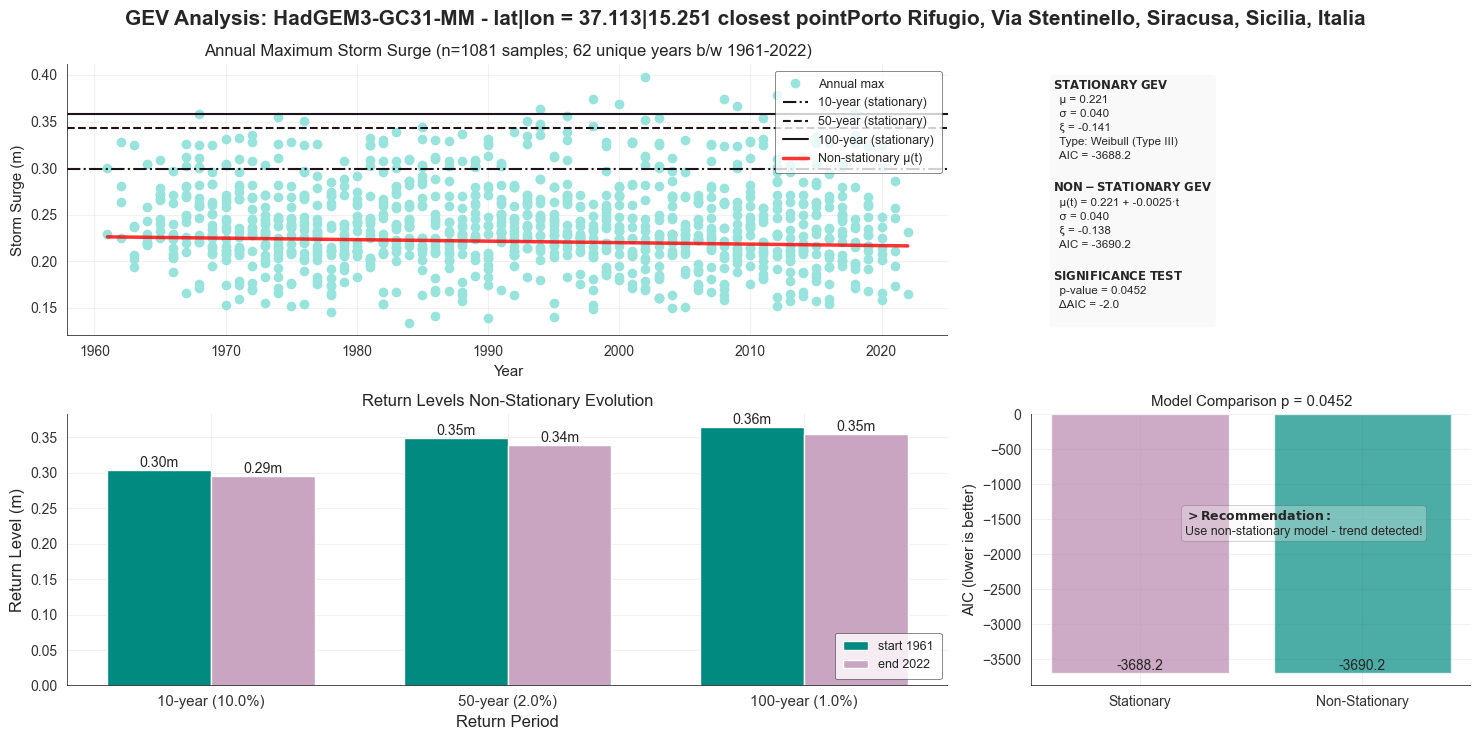

In [74]:
ls_messages = []
print_msg = True

if result_display:
    lat, lon = result_display['location'][0], result_display['location'][1]
    sim_years = result_display['annual_maxima'].year
    
    ls_messages = ut.adding_plot_and_text("\n" + "="*100, ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(
        f"RESULTS for {example_model} - location {lat:.5f}|{lon:.5f} (lat|lon)", ls_messages, print_msg
        )
    ls_messages = ut.adding_plot_and_text("="*100, ls_messages, print_msg)
    
    ls_messages = ut.adding_plot_and_text(f"\nClosest location identified: {location_choice}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(
        f"Hindcast period: {int(sim_years.unique().min())}-{int(sim_years.unique().max())} "
        f"({len(sim_years.unique())} unique years)", ls_messages, print_msg
        )
    ls_messages = ut.adding_plot_and_text(f"Observations per year: ~2 (from ensemble members)", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(
        f"Total data points for GEV: {result_display['gev_stationary']['n_obs']}", ls_messages, print_msg
        )

    ls_messages = ut.adding_plot_and_text("\nSTATIONARY GEV", ls_messages, print_msg)
    stat = result_display['gev_stationary']
    ls_messages = ut.adding_plot_and_text(f"  μ (location) = {stat['location']:.3f}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"  σ (scale) = {stat['scale']:.3f}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"  ξ (shape) = {stat['shape']:.3f}", ls_messages, print_msg)
    ls_messages = ut.adding_plot_and_text(f"  Type: {stat['dist_type']}", ls_messages, print_msg)

    ls_messages = ut.adding_plot_and_text(f"  Return Level", ls_messages, print_msg)
    for x, v in result_display['return_levels_stationary'].items():
        aep = 100/int(x.split('-')[0])
        ls_messages = ut.adding_plot_and_text(
            f"  \tFor {x} period: {v:.3f} m ({aep}% annual exceedance probability)", ls_messages, print_msg
            )

    if result_display['gev_nonstationary']:
        ls_messages = ut.adding_plot_and_text("\nNON-STATIONARY GEV", ls_messages, print_msg)
        nonstat = result_display['gev_nonstationary']
        ls_messages = ut.adding_plot_and_text(f"  μ(t) = {nonstat['mu0']:.3f} + {nonstat['mu1']:.4f}·t", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  Trend = {nonstat['mu1'] * nonstat['years_std']:.4f} m/year", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  Return Level Evolution", ls_messages, print_msg)
        for x,y in zip(
            result_display['return_levels_nonstationary_start']['values'].items(), 
            result_display['return_levels_nonstationary_end']['values'].items()
            ):

            period = x[0]
            aep = 100/int(period.split('-')[0])
            ls_messages = ut.adding_plot_and_text(
                f"  \tFor {period} period: {x[1]:.3f}m - {y[1]:.3f}m ({aep}% annual exceedance probability)",
                ls_messages, print_msg
            )

    if result_display['model_comparison']:
        ls_messages = ut.adding_plot_and_text("\nMODEL COMPARISON", ls_messages, print_msg)
        comp = result_display['model_comparison']
        ls_messages = ut.adding_plot_and_text(f"  p-value: {comp['p_value']:.4f}", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  Decision: {comp['decision']}", ls_messages, print_msg)
        ls_messages = ut.adding_plot_and_text(f"  → {comp['recommendation']}", ls_messages, print_msg)

    # Store messages (GEV analysis parameters) as txt
    today_ = str(datetime.today().date().isoformat())
    save_path = path_export + today_
    Path(save_path).mkdir(parents=True, exist_ok=True)            
    country = result_display['location info'].split(',')[-1].strip()
    lat_str = str(round(float(result_display['location'][0]), 3))
    lon_str = str(round(float(result_display['location'][1]),3))
    
    with open(save_path + f"/GEVanalysis_{example_model}_{country}_{lat_str}|{lon_str}_{today_}.txt", 'w') as f:
        f.write('\n'.join(ls_messages))
    
    print("\nVISUALIZE RESULTS")
    dbplt.plot_analysis(
        results=results, 
        model=example_model, 
        lat_lon_tuple=result_display['location'], 
        location_info=result_display['location info'],
        periods_evolution = plot_period_evolution,
        box_parameters_x=0.05, box_parameters_y=0.95,
        width_bar_returns=0.35,
        leg_comparison_x=0.35, leg_comparison_y=0.65, linespace=1.5,
        save_path = save_path,
        color_markers='#99E3DDFF', 
        colors_trends='#1D141BFF', 
        colors_models=['#B887ADFF', '#008A80FF'],
        colors_return_levels=['#008A80FF','#CAA5C2FF'],
        bbox_color='#F5F5F5FF',
        axes_color='#333333', 
        linestyle_trends=['dashdot', 'dashed', 'solid'], 
        fontsize=12, figsize=(15, 7.5),
    )